<a href="https://colab.research.google.com/github/AlexanderOlivera/Analisis-de-algoritmos/blob/main/Programacion_dinamica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎒 Tarea: Programación Dinámica y el Problema de la Mochila 0/1

## 📘 Materia
Diseño y Análisis de Algoritmos

## 🎯 Objetivo de la actividad
En esta tarea vas a resolver experimentalmente el **problema de la mochila 0/1** usando tres enfoques:

1. **Versión recursiva sin Programación Dinámica**
2. **Versión top-down con memoización**
3. **Versión bottom-up con tabulación**

El propósito es que puedas:

- identificar la diferencia entre una solución recursiva ingenua y una solución con Programación Dinámica;
- implementar correctamente los tres enfoques;
- verificar experimentalmente que producen el mismo resultado;
- comparar su rendimiento;
- interpretar el crecimiento del costo del algoritmo a partir de gráficas experimentales.

---

## 🧩 Descripción del problema
Dado un conjunto de objetos, cada uno con:

- un **peso**,
- un **valor**,

y una mochila con capacidad máxima `W`, debes determinar cuál es el **valor máximo total** que puede transportarse sin exceder la capacidad.

En la variante **0/1**, cada objeto:
- o se toma una sola vez,
- o no se toma.

No se puede fraccionar.

---

## ✅ Lo que debes hacer

### Parte 1. Implementación
Debes programar las siguientes funciones:

- `knapsack_recursive(weights, values, capacity, n)`
- `knapsack_top_down(weights, values, capacity)`
- `knapsack_bottom_up(weights, values, capacity)`

### Parte 2. Validación
Usarás el entorno de pruebas de este notebook para verificar que tus implementaciones producen el valor óptimo esperado.

### Parte 3. Análisis experimental
Vas a ejecutar experimentos para comparar los tiempos de ejecución y visualizar el crecimiento del costo experimental.

### Parte 4. Reflexión
Responderás al final algunas preguntas sobre la diferencia entre los tres enfoques.


# 📂 Conjunto de datos

En este notebook se usará un archivo CSV con instancias del problema de mochila con 5 objetos.

Cada fila incluye:

- lista de pesos,
- lista de valores/precios,
- capacidad,
- selección óptima esperada,
- valor óptimo esperado.

Este archivo se utilizará para validar automáticamente tus funciones.


In [ ]:
import ast
import time
import math
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from functools import lru_cache
from kagglehub import KaggleDatasetAdapter


# 1. Carga de datos

Ejecuta esta celda para cargar el archivo.


In [ ]:
DATA_PATH = "knapsack_5_items.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "warcoder/knapsack-problem",
  DATA_PATH,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("Número de instancias:", len(df))
df.head()


/tmp/ipykernel_17324/1911454581.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'knapsack-problem' dataset.
Número de instancias: 10000


,Weights,Prices,Capacity,Best picks,Best price
0,[46 40 42 38 10],[12 19 19 15 8],40,[0. 1. 0. 0. 0.],19.0
1,[11 31 4 6 7],[ 2 8 18 16 3],64,[1. 1. 1. 1. 1.],47.0
2,[32 49 27 37 24],[19 16 16 4 1],87,[1. 0. 1. 0. 1.],36.0
3,[20 35 22 23 16],[19 17 19 9 1],21,[1. 0. 0. 0. 0.],19.0
4,[ 7 12 19 13 20],[10 11 18 15 5],50,[0. 1. 1. 1. 0.],44.0


## 1.1 Funciones auxiliares para convertir los datos

Las columnas del CSV vienen como texto, por lo que necesitamos transformarlas a listas numéricas.


In [ ]:
def parse_space_array(text):
    text = str(text).strip()
    text = text.strip("[]").strip()
    if not text:
        return []
    return [int(float(x)) for x in text.split()]

def parse_instance(row):
    weights = parse_space_array(row["Weights"])
    values = parse_space_array(row["Prices"])
    capacity = int(row["Capacity"])
    best_picks = parse_space_array(row["Best picks"])
    best_price = int(float(row["Best price"]))
    return weights, values, capacity, best_picks, best_price

# Ejemplo de una instancia
weights, values, capacity, best_picks, best_price = parse_instance(df.iloc[0])
print("weights =", weights)
print("values  =", values)
print("capacity =", capacity)
print("best picks =", best_picks)
print("best price =", best_price)


weights = [46, 40, 42, 38, 10]
values  = [12, 19, 19, 15, 8]
capacity = 40
best picks = [0, 1, 0, 0, 0]
best price = 19


# 2. Implementación solicitada

## ⚠️ Instrucciones
Debes completar las funciones siguientes.

### Requisitos:
- La versión recursiva debe trabajar con la idea clásica de incluir/no incluir el objeto actual.
- La versión top-down debe usar memoización.
- La versión bottom-up debe construir una tabla iterativamente.
- Todas deben devolver el **valor máximo** que puede obtenerse.

> En esta tarea el entorno de prueba verifica el **valor óptimo**, no necesariamente la lista de objetos elegidos.


## 2.1 Versión recursiva sin Programación Dinámica


In [ ]:
def knapsack_recursive(weights, values, capacity, n):
    if n == 0 or capacity == 0:
        return 0

    if weights[n-1] > capacity:
        return knapsack_recursive(weights, values, capacity, n-1)
    else:
        return max(
            values[n-1] + knapsack_recursive(weights, values, capacity - weights[n-1], n-1),
            knapsack_recursive(weights, values, capacity, n-1)
        )

## 2.2 Versión top-down con memoización


In [ ]:
def knapsack_top_down(weights, values, capacity):
    n = len(values)
    memo = [[-1 for _ in range(capacity + 1)] for _ in range(n + 1)]

    def solve(c, i):
        if i == 0 or c == 0:
            return 0
        if memo[i][c] != -1:
            return memo[i][c]

        if weights[i-1] > c:
            memo[i][c] = solve(c, i-1)
        else:
            memo[i][c] = max(
                values[i-1] + solve(c - weights[i-1], i-1),
                solve(c, i-1)
            )
        return memo[i][c]

    return solve(capacity, n)


## 2.3 Versión bottom-up con tabulación


In [ ]:
def knapsack_bottom_up(weights, values, capacity):
    n = len(values)
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(1, capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(values[i-1] + dp[i-1][w - weights[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]

    return dp[n][capacity]

# 3. Entorno de pruebas: validación funcional

Las siguientes celdas te permiten verificar si tus funciones están calculando correctamente el valor óptimo esperado.

Se comparan tus resultados contra el valor óptimo almacenado en el CSV.


In [ ]:
def test_single_instance(index=0, verbose=True):
    row = df.iloc[index]
    weights, values, capacity, best_picks, best_price = parse_instance(row)
    n = len(weights)

    r1 = knapsack_recursive(weights, values, capacity, n)
    r2 = knapsack_top_down(weights, values, capacity)
    r3 = knapsack_bottom_up(weights, values, capacity)

    if verbose:
        print(f"Instancia {index}")
        print("weights =", weights)
        print("values  =", values)
        print("capacity =", capacity)
        print("expected best price =", best_price)
        print("recursive =", r1)
        print("top-down  =", r2)
        print("bottom-up =", r3)

    return (r1 == best_price) and (r2 == best_price) and (r3 == best_price)


In [ ]:
# Descomenta esta línea cuando hayas implementado las funciones:
print("¿Prueba individual correcta?:", test_single_instance(0))


Instancia 0
weights = [46, 40, 42, 38, 10]
values  = [12, 19, 19, 15, 8]
capacity = 40
expected best price = 19
recursive = 19
top-down  = 19
bottom-up = 19
¿Prueba individual correcta?: True


## 3.1 Prueba por lote sobre varias instancias


In [ ]:
def test_batch(num_cases=20):
    ok = 0
    for i in range(num_cases):
        row = df.iloc[i]
        weights, values, capacity, best_picks, best_price = parse_instance(row)
        n = len(weights)

        r1 = knapsack_recursive(weights, values, capacity, n)
        r2 = knapsack_top_down(weights, values, capacity)
        r3 = knapsack_bottom_up(weights, values, capacity)

        if r1 == best_price and r2 == best_price and r3 == best_price:
            ok += 1
        else:
            print(f"Error en instancia {i}: esperado={best_price}, rec={r1}, td={r2}, bu={r3}")

    print(f"Casos correctos: {ok}/{num_cases}")
    return ok == num_cases


In [ ]:
# Descomenta cuando implementes:
test_batch(20)


Casos correctos: 20/20


True

# 4. Experimentos de rendimiento

Ahora vamos a comparar el tiempo de ejecución de los tres enfoques.

## ⚠️ Importante
La base cargada tiene instancias de 5 objetos, lo cual es útil para validar corrección, pero no es suficiente para apreciar claramente la diferencia de rendimiento entre enfoques.

Por eso, para el análisis experimental también generaremos instancias aleatorias con distintos tamaños `n`.


In [ ]:
def medir_tiempo(func, *args, repeticiones=1):
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        func(*args)
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
    return sum(tiempos) / len(tiempos)

def generar_instancia_mochila(n, max_weight=30, max_value=40, capacity_ratio=0.45, seed=None):
    import random
    if seed is not None:
        random.seed(seed)
    weights = [random.randint(1, max_weight) for _ in range(n)]
    values = [random.randint(1, max_value) for _ in range(n)]
    capacity = max(1, int(sum(weights) * capacity_ratio))
    return weights, values, capacity


## 4.1 Experimento 1: crecimiento del tiempo con respecto al número de objetos

Aquí mediremos tiempo promedio para instancias generadas aleatoriamente.

### Sugerencia didáctica:
- la versión recursiva ingenua se vuelve costosa rápidamente;
- por eso se probará con tamaños más pequeños;
- las versiones con PD podrán evaluarse con tamaños mayores.


In [ ]:
ns_recursive = list(range(1, 31, 2))
times_recursive = []

for n in ns_recursive:
    weights, values, capacity = generar_instancia_mochila(n, seed=n)
    times_recursive.append(medir_tiempo(knapsack_recursive, weights, values, capacity, len(weights), repeticiones=1))


In [ ]:
ns_dp = list(range(5, 101, 5))
times_top_down = []
times_bottom_up = []

for n in ns_dp:
    weights, values, capacity = generar_instancia_mochila(n, seed=n)
    times_top_down.append(medir_tiempo(knapsack_top_down, weights, values, capacity, repeticiones=3))
    times_bottom_up.append(medir_tiempo(knapsack_bottom_up, weights, values, capacity, repeticiones=3))


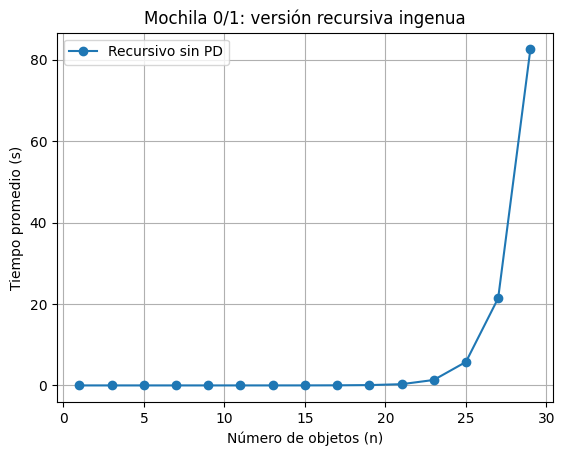

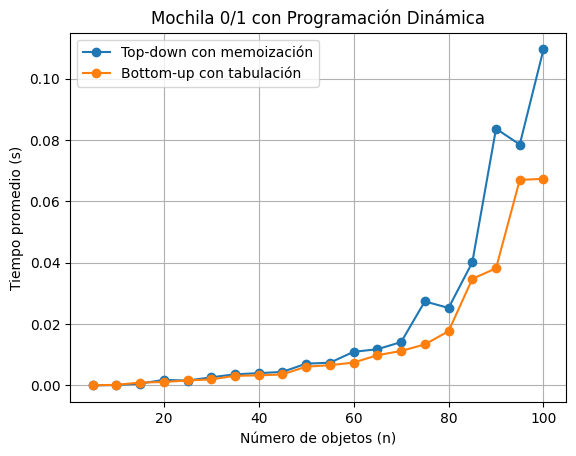

In [ ]:
plt.figure()
plt.plot(ns_recursive, times_recursive, marker="o", label="Recursivo sin PD")
plt.xlabel("Número de objetos (n)")
plt.ylabel("Tiempo promedio (s)")
plt.title("Mochila 0/1: versión recursiva ingenua")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(ns_dp, times_top_down, marker="o", label="Top-down con memoización")
plt.plot(ns_dp, times_bottom_up, marker="o", label="Bottom-up con tabulación")
plt.xlabel("Número de objetos (n)")
plt.ylabel("Tiempo promedio (s)")
plt.title("Mochila 0/1 con Programación Dinámica")
plt.grid(True)
plt.legend()
plt.show()


# 5. Curvas de referencia para interpretar el costo experimental

En la mochila 0/1:
- la versión recursiva ingenua suele mostrar crecimiento exponencial respecto a `n`;
- las versiones con Programación Dinámica dependen tanto de `n` como de la capacidad `W`.

Aquí haremos una comparación **cualitativa**:
- una referencia exponencial para la versión recursiva;
- una referencia tipo `n * W` para las versiones con PD.


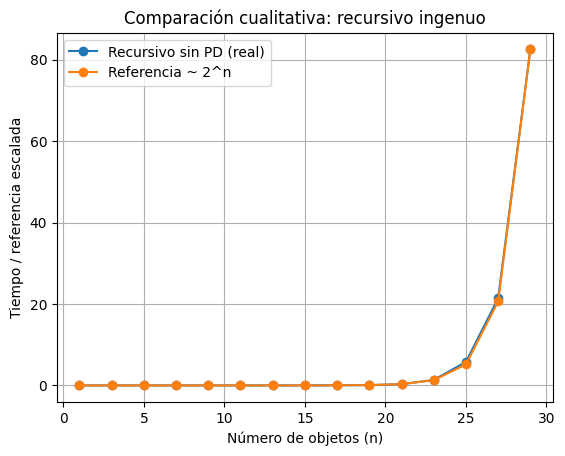

In [ ]:
# Referencia exponencial (escalada) para la versión recursiva
ref_exp = [2**n for n in ns_recursive]
scale_exp = times_recursive[-1] / ref_exp[-1] if ref_exp[-1] != 0 else 1
ref_exp_scaled = [x * scale_exp for x in ref_exp]

plt.figure()
plt.plot(ns_recursive, times_recursive, marker="o", label="Recursivo sin PD (real)")
plt.plot(ns_recursive, ref_exp_scaled, marker="o", label="Referencia ~ 2^n")
plt.xlabel("Número de objetos (n)")
plt.ylabel("Tiempo / referencia escalada")
plt.title("Comparación cualitativa: recursivo ingenuo")
plt.grid(True)
plt.legend()
plt.show()


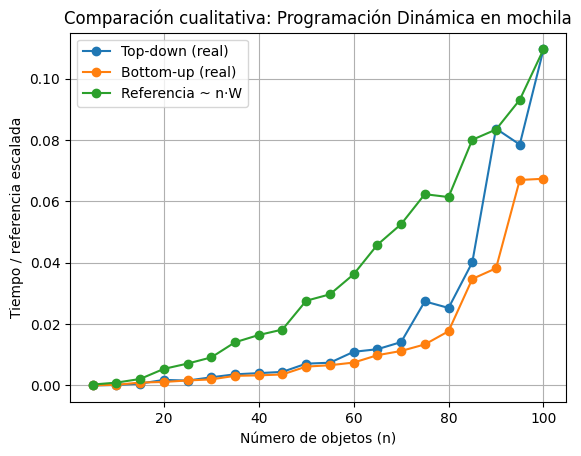

In [ ]:
# Referencia n*W para las versiones DP
nw_reference = []
capacities_dp = []

for n in ns_dp:
    weights, values, capacity = generar_instancia_mochila(n, seed=n)
    capacities_dp.append(capacity)
    nw_reference.append(n * capacity)

scale_td = times_top_down[-1] / nw_reference[-1] if nw_reference[-1] != 0 else 1
ref_nw_scaled = [x * scale_td for x in nw_reference]

plt.figure()
plt.plot(ns_dp, times_top_down, marker="o", label="Top-down (real)")
plt.plot(ns_dp, times_bottom_up, marker="o", label="Bottom-up (real)")
plt.plot(ns_dp, ref_nw_scaled, marker="o", label="Referencia ~ n·W")
plt.xlabel("Número de objetos (n)")
plt.ylabel("Tiempo / referencia escalada")
plt.title("Comparación cualitativa: Programación Dinámica en mochila")
plt.grid(True)
plt.legend()
plt.show()


# 6. Visualización opcional de la tabla DP (bottom-up)

Esta sección es útil para observar cómo se construye la solución iterativamente.
Puedes completarla si deseas profundizar más en el funcionamiento del enfoque bottom-up.


In [ ]:
def knapsack_bottom_up_table(weights, values, capacity):
    n = len(values)
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(1, capacity + 1):
            # Si el peso del objeto actual es menor o igual a la capacidad actual 'w'
            if weights[i-1] <= w:
                # Consideramos dos opciones: incluir el objeto o no incluirlo
                # 1. Incluir el objeto: valor del objeto + valor máximo de los objetos restantes con la capacidad reducida
                # 2. No incluir el objeto: valor máximo de los objetos anteriores con la misma capacidad
                dp[i][w] = max(values[i-1] + dp[i-1][w - weights[i-1]], dp[i-1][w])
            else:
                # Si el peso del objeto actual es mayor que la capacidad actual 'w', no podemos incluirlo
                # por lo que el valor máximo es el mismo que el de los objetos anteriores con la misma capacidad
                dp[i][w] = dp[i-1][w]

    return dp

In [ ]:
# Descomenta si implementas la función opcional:
weights, values, capacity = generar_instancia_mochila(5, seed=42)
table = knapsack_bottom_up_table(weights, values, capacity)
pd.DataFrame(table)

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,16,16,16,16,16,16
2,0,0,0,0,15,15,15,15,15,15,...,15,15,15,15,16,16,16,16,31,31
3,0,9,9,9,15,24,24,24,24,24,...,24,24,24,24,24,25,25,25,31,40
4,0,9,9,9,15,24,24,24,24,24,...,24,24,24,24,24,25,25,25,31,40
5,0,9,9,9,15,24,24,24,24,35,...,59,59,59,59,59,59,59,59,59,59


# 7. Preguntas de reflexión

Responde estas preguntas en una celda Markdown al final del notebook:

1. ¿Qué diferencia conceptual existe entre la versión recursiva ingenua y la versión top-down?
2. ¿Por qué la Programación Dinámica evita trabajo repetido?
3. ¿Qué semejanza y diferencia encuentras entre top-down y bottom-up?
4. ¿Qué patrón observas en la curva experimental del algoritmo recursivo?
5. ¿Por qué las versiones con PD dependen también de la capacidad `W`?
6. ¿Qué enfoque te parece más claro para implementar: top-down o bottom-up? Justifica.


**1. ¿Qué diferencia conceptual existe entre la versión recursiva ingenua y la versión top-down?**

La versión recursiva ingenua explora todas las combinaciones posibles, evaluando los mismos subproblemas múltiples veces. La versión top-down es la misma aproximación recursiva, pero incorpora memoización, guarda los resultados de cada subproblema resuelto en una matriz para consultarlos si se repiten, en lugar de volver a calcularlos.

**2. ¿Por qué la Programación Dinámica evita trabajo repetido?**

Porque explota la propiedad de superposición de subproblemas. Al almacenar en memoria el resultado de un subproblema la primera vez que se calcula, cualquier petición futura a ese mismo cálculo se resuelve recuperando el valor guardado en tiempo constante $\mathcal{O}(1)$, cortando ramas enteras del árbol de ejecución.

**3. ¿Qué semejanza y diferencia encuentras entre top-down y bottom-up?**

* **Semejanza:** Ambos son métodos de Programación Dinámica que garantizan resolver cada subproblema una sola vez utilizando memoria extra para almacenar resultados.
* **Diferencia:** *Top-down* es recursivo (empieza por el problema grande hasta llegar a los casos base) y solo resuelve los subproblemas estrictamente necesarios. *Bottom-up* es iterativo (empieza desde los casos base construyendo la solución hasta el problema original) y suele llenar la tabla completa, pero evita la sobrecarga y el límite de profundidad en la pila de llamadas del sistema.

**4. ¿Qué patrón observas en la curva experimental del algoritmo recursivo?**

Muestra un crecimiento exponencial. Su complejidad temporal es de $\mathcal{O}(2^n)$. Con cada objeto adicional ($n$) que se agrega al problema, el tiempo de ejecución prácticamente se duplica, haciendo que la gráfica se dispare rápidamente y el algoritmo se vuelva inútil para valores medianos o grandes.

**5. ¿Por qué las versiones con PD dependen también de la capacidad $W$?**

Porque la cantidad de subproblemas únicos (estados) se define por dos variables: la cantidad de objetos considerados ($i$) y la capacidad restante en la mochila ($w$). La estructura de almacenamiento (matriz) tiene dimensiones $(n+1) \times (W+1)$. Por lo tanto, el algoritmo debe iterar o hacer búsquedas sobre esa cuadrícula, resultando en un tiempo de ejecución proporcional tanto a $n$ como a $W$ (complejidad seudopolinomial $\mathcal{O}(nW)$).

**6. ¿Qué enfoque te parece más claro para implementar: top-down o bottom-up? Justifica.**
*Top-down* suele ser más intuitivo al principio porque es simplemente la fórmula recursiva matemática literal a la que se le agregan un par de líneas para checar/guardar en caché. Sin embargo, *Bottom-up* termina siendo más robusto y claro a nivel de sistema: al usar bucles anidados (`for`), te olvidas del límite de recursividad de Python (`RecursionError`) y el flujo de ejecución es completamente lineal y predecible.

# 8. Entregable esperado

Tu notebook debe incluir:

- implementación completa de los tres algoritmos;
- ejecución de las pruebas;
- gráficas de rendimiento;
- interpretación de las curvas experimentales;
- respuestas a las preguntas de reflexión.

⚠️ No modifiques el entorno de pruebas para “forzar” que pase.
La idea es que el código correcto funcione con las pruebas tal como están planteadas.
